<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/53_model_persistence_joblib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import joblib

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

print("Dataset Shape:", X.shape)

Dataset Shape: (500, 10)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [5]:
pred_original = model.predict(
    X_test
)

accuracy_original = accuracy_score(
    y_test,
    pred_original
)

print(
    "Original Accuracy:",
    round(accuracy_original,4)
)

Original Accuracy: 0.92


In [6]:
joblib.dump(
    model,
    "random_forest_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [7]:
loaded_model = joblib.load(
    "random_forest_model.pkl"
)

print(
    "Model Loaded Successfully"
)

Model Loaded Successfully


In [8]:
pred_loaded = loaded_model.predict(
    X_test
)

accuracy_loaded = accuracy_score(
    y_test,
    pred_loaded
)

print(
    "Loaded Model Accuracy:",
    round(accuracy_loaded,4)
)

Loaded Model Accuracy: 0.92


In [9]:
print(
    "Predictions Identical:",
    np.array_equal(
        pred_original,
        pred_loaded
    )
)

Predictions Identical: True


In [10]:
comparison = pd.DataFrame({
    "Model Version":[
        "Original Model",
        "Loaded Model"
    ],

    "Accuracy":[
        accuracy_original,
        accuracy_loaded
    ]
})

comparison

,Model Version,Accuracy
0,Original Model,0.92
1,Loaded Model,0.92


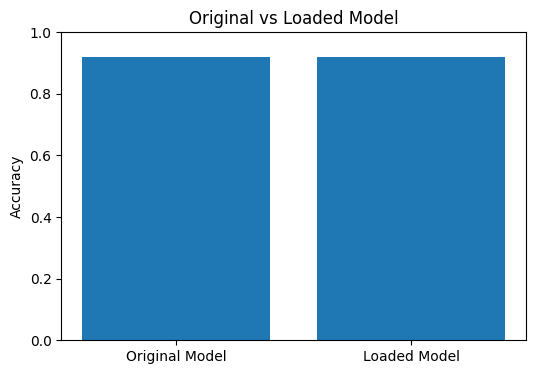

In [11]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model Version"],
    comparison["Accuracy"]
)

plt.ylim(0,1)

plt.title(
    "Original vs Loaded Model"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [12]:
new_data = [X_test[0]]

prediction = loaded_model.predict(
    new_data
)

print(
    "Prediction for New Sample:",
    prediction[0]
)

Prediction for New Sample: 0


In [13]:
import os

print(
    "File Exists:",
    os.path.exists(
        "random_forest_model.pkl"
    )
)

File Exists: True


## Conclusion

Model persistence was implemented using Joblib.

Observations:
- The trained Random Forest model was saved to disk.
- The saved model was loaded without retraining.
- Predictions from the loaded model matched the original model exactly.
- Model persistence enables efficient reuse and deployment of machine learning models.